In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
csv_path = 'team_record.csv'
df = pd.read_csv(csv_path)
df

,시즌,모든 경기,일반 경기,자체전,승점,승,무,패,득점,실점,득실차
0,2022,31,29,2,53,17,2,10,138,122,16
1,2023,40,39,1,91,29,4,6,225,130,95
2,2024,40,38,2,71,23,2,13,200,156,44
3,2025,35,35,0,53,15,8,12,183,157,26
4,2026,26,25,1,49,15,4,6,155,114,41


In [21]:
df = df.drop(columns = ["모든 경기", "자체전","승점"])
df

,시즌,일반 경기,승,무,패,득점,실점,득실차
0,2022,29,17,2,10,138,122,16
1,2023,39,29,4,6,225,130,95
2,2024,38,23,2,13,200,156,44
3,2025,35,15,8,12,183,157,26
4,2026,25,15,4,6,155,114,41


In [27]:

df = df.rename(
    columns={
        '시즌':'Season',
        '일반 경기':'Played',
        '승':'Win',
        '무':'Draw',
        '패':'Lose',
        '득점':'Goals For',
        '실점':'Goals Against',
        '득실차':'Goal Difference'
    }
)

df.insert(
    loc=df.columns.get_loc("Lose") + 1,
    column="Win Rate(%)",
    value=(df["Win"] / df["Played"] * 100).round().astype(int)
)

df

,Season,Played,Win,Draw,Lose,Win Rate(%),Goals For,Goals Against,Goal Difference
0,2022,29,17,2,10,59,138,122,16
1,2023,39,29,4,6,74,225,130,95
2,2024,38,23,2,13,61,200,156,44
3,2025,35,15,8,12,43,183,157,26
4,2026,25,15,4,6,60,155,114,41


ValueError: cannot insert Win Rate(%), already exists

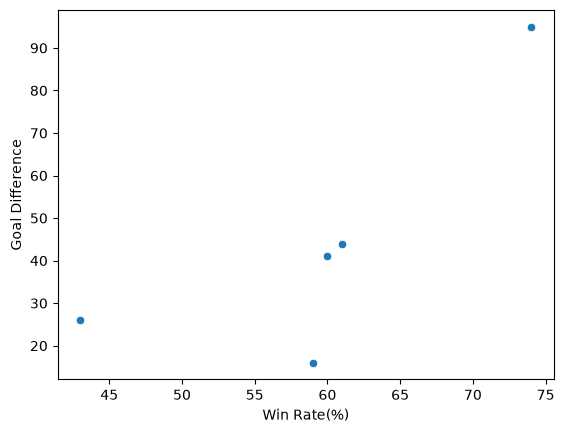

In [32]:
sns.scatterplot(
    data=df,
    x='Win Rate(%)',
    y='Goal Difference'
)

plt.show()